# Bias Detection, Mitigation and Explainability in ML Models
## Comprehensive Multi-Dataset Research Pipeline (IEEE Compliant Version)

This notebook presents a comprehensive research pipeline evaluating bias detection, mitigation, and explainability across three standard benchmark datasets:
1. **Adult Income Dataset** (sensitive attribute: `sex`)
2. **COMPAS Recidivism Dataset** (sensitive attribute: `race`)
3. **Statlog German Credit Dataset** (sensitive attribute: `age`)

### Pipeline Overview:
* **Model Baselines**: Logistic Regression (LR), Random Forest (RF), and a Standard Artificial Neural Network (ANN) using `MLPClassifier` to isolate the effects of debiasing.
* **Pre-processing Mitigation**: Reweighing (using AIF360) applied to adjust training set sample weights.
* **Post-processing Mitigation**: Threshold Optimization / Calibrated Equalized Odds (using Fairlearn) to adjust model classification boundaries.
* **In-processing Mitigation**: Adversarial Debiasing (using AIF360) executed across multiple random initializations to compute variance (mean and standard deviation).
* **Explainability**: SHAP Interaction Analysis to visualize joint feature contributions and inspect potential indirect bias.
* **Causal Validation**: Feature ablation studies to quantify the impact of removing suspected demographic proxy features on accuracy and fairness.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier  # Added for Standard ANN Baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    true_positive_rate_difference,
    false_positive_rate_difference
)

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.metrics import ClassificationMetric

# Apply IEEE-compliant clean light theme for presentation visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d3d3d3",
    "grid.color": "#e5e5e5",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})


pip install 'aif360[inFairness]'


## 2. Advanced Metric Calculation Functions

We define helper functions to compute traditional classification performance metrics and standard fairness metrics:
* **Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, and ROC AUC** to track predictive performance.
* **Statistical Parity Difference (SPD)**, **Disparate Impact (DI)**, **Equal Opportunity (EO) Difference**, and **Average Odds Difference (AOD)** to track fairness criteria.


In [2]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    """
    Computes a comprehensive suite of performance evaluation metrics to strictly
    satisfy Reviewer 3's request for enhanced analytical breadth.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        metrics["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC_AUC"] = np.nan

    return metrics

def fairness_metrics(y_true, y_pred, protected):
    """
    Computes standard fairness metrics mapping mathematical formulations to
    core criteria requested for a complete trustworthiness profile.
    """
    spd = demographic_parity_difference(y_true, y_pred, sensitive_features=protected)
    di = demographic_parity_ratio(y_true, y_pred, sensitive_features=protected)
    eo = true_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    fpr_diff = false_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    aod = (eo + fpr_diff) / 2

    return spd, di, eo, aod


## 3. Modular Runner for Bias Detection & Mitigation Pipeline

Here, we implement the unified processing pipeline runner. It executes:
1. **Baseline classification models** (Logistic Regression, Random Forest, and a multi-run Standard Artificial Neural Network to track weight initialization variance).
2. **Pre-processing (Reweighing)** on training weights and re-training Logistic Regression.
3. **Post-processing (Threshold Optimization)** with Calibrated Equalized Odds criteria.
4. **In-processing (Adversarial Debiasing)** run across 5 different initializations to measure performance and fairness variance.
5. **IEEE-compliant plot generators** to display comparative Statistical Parity Difference (SPD) and Equal Opportunity (EO) metrics.


In [3]:
def run_fairness_pipeline(X_train_scaled, X_test_scaled, y_train, y_test, prot_train, prot_test, feature_names, dataset_name, prot_col):
    """
    Encapsulates training, validation, and multi-stage mitigation execution.
    Includes Standard ANN Baseline and multi-run Adversarial variance tracking.
    """
    print(f"\nProcessing Pipeline for: {dataset_name.upper()}...")
    num_runs = 5

    # --- BASELINE INFERENCE (LR, RF) ---
    lr = LogisticRegression(max_iter=3000, random_state=42)
    rf = RandomForestClassifier(n_estimators=50, random_state=42)

    lr.fit(X_train_scaled, y_train)
    rf.fit(X_train_scaled, y_train)

    y_pred_lr, y_prob_lr = lr.predict(X_test_scaled), lr.predict_proba(X_test_scaled)[:, 1]
    y_pred_rf, y_prob_rf = rf.predict(X_test_scaled), rf.predict_proba(X_test_scaled)[:, 1]

    metrics_lr = calculate_metrics(y_test, y_pred_lr, y_prob_lr)
    metrics_rf = calculate_metrics(y_test, y_pred_rf, y_prob_rf)

    spd_lr, di_lr, eo_lr, aod_lr = fairness_metrics(y_test, y_pred_lr, prot_test)
    spd_rf, di_rf, eo_rf, aod_rf = fairness_metrics(y_test, y_pred_rf, prot_test)

    # --- BASELINE ANN (5 runs to track weight initialization variance) ---
    print("Running Baseline ANN across multiple initializations...")
    ann_metrics_list = []
    ann_spd, ann_di, ann_eo, ann_aod = [], [], [], []
    for seed in range(42, 42 + num_runs):
        ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=200, random_state=seed)
        ann.fit(X_train_scaled, y_train)
        y_pred_ann, y_prob_ann = ann.predict(X_test_scaled), ann.predict_proba(X_test_scaled)[:, 1]

        m_ann = calculate_metrics(y_test, y_pred_ann, y_prob_ann)
        s_ann, d_ann, e_ann, a_ann = fairness_metrics(y_test, y_pred_ann, prot_test)

        ann_metrics_list.append(m_ann)
        ann_spd.append(s_ann); ann_di.append(d_ann)
        ann_eo.append(e_ann); ann_aod.append(a_ann)

    ann_metrics_mean = {k: np.mean([m[k] for m in ann_metrics_list]) for k in ann_metrics_list[0].keys()}
    ann_metrics_std = {k: np.std([m[k] for m in ann_metrics_list]) for k in ann_metrics_list[0].keys()}
    mean_spd_ann, std_spd_ann = np.mean(ann_spd), np.std(ann_spd)
    mean_di_ann, std_di_ann = np.mean(ann_di), np.std(ann_di)
    mean_eo_ann, std_eo_ann = np.mean(ann_eo), np.std(ann_eo)
    mean_aod_ann, std_aod_ann = np.mean(ann_aod), np.std(ann_aod)

    # --- PRE-PROCESSING MITIGATION (REWEIGHTING) ---
    train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    train_df["target"] = y_train.values
    train_df[prot_col] = prot_train.values

    aif_train = BinaryLabelDataset(df=train_df, label_names=["target"], protected_attribute_names=[prot_col])
    RW = Reweighing(unprivileged_groups=[{prot_col: 0}], privileged_groups=[{prot_col: 1}])
    aif_train_transf = RW.fit_transform(aif_train)
    sample_weights = aif_train_transf.instance_weights

    lr_rw = LogisticRegression(max_iter=3000, random_state=42)
    lr_rw.fit(X_train_scaled, y_train, sample_weight=sample_weights)

    y_pred_rw, y_prob_rw = lr_rw.predict(X_test_scaled), lr_rw.predict_proba(X_test_scaled)[:, 1]
    metrics_rw = calculate_metrics(y_test, y_pred_rw, y_prob_rw)
    spd_rw, di_rw, eo_rw, aod_rw = fairness_metrics(y_test, y_pred_rw, prot_test)

    # --- POST-PROCESSING MITIGATION (THRESHOLD OPTIMIZATION) ---
    thresh = ThresholdOptimizer(estimator=lr, constraints="equalized_odds", predict_method="predict_proba")
    thresh.fit(X_train_scaled, y_train, sensitive_features=prot_train)

    y_pred_thresh = thresh.predict(X_test_scaled, sensitive_features=prot_test)
    metrics_thresh = calculate_metrics(y_test, y_pred_thresh, y_prob=None)
    spd_thresh, di_thresh, eo_thresh, aod_thresh = fairness_metrics(y_test, y_pred_thresh, prot_test)

    # --- IN-PROCESSING MITIGATION (ADVERSARIAL DEBIASING WITH VARIANCE TRACKING) ---
    tf.compat.v1.disable_eager_execution()
    test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
    test_df["target"] = y_test.values
    test_df[prot_col] = prot_test.values
    aif_test = BinaryLabelDataset(df=test_df, label_names=["target"], protected_attribute_names=[prot_col])

    adv_metrics_list = []
    adv_spd, adv_di, adv_eo, adv_aod = [], [], [], []

    print("Running Adversarial Debiasing across multiple initializations to track variance...")
    for run_idx, seed in enumerate(range(42, 42 + num_runs)):
        tf.compat.v1.reset_default_graph()
        tf.compat.v1.set_random_seed(seed)
        np.random.seed(seed)
        sess = tf.compat.v1.Session()

        adv = AdversarialDebiasing(
            privileged_groups=[{prot_col: 1}],
            unprivileged_groups=[{prot_col: 0}],
            scope_name=f"adv_{dataset_name}_{run_idx}",
            sess=sess,
            num_epochs=50
        )
        adv.fit(aif_train)
        pred_adv = adv.predict(aif_test)
        y_pred_adv = pred_adv.labels.ravel()

        m_adv = calculate_metrics(y_test, y_pred_adv, y_prob=None)
        s_adv, d_adv, e_adv, a_adv = fairness_metrics(y_test, y_pred_adv, prot_test)
        
        adv_metrics_list.append(m_adv)
        adv_spd.append(s_adv); adv_di.append(d_adv)
        adv_eo.append(e_adv); adv_aod.append(a_adv)
        sess.close()

    # Calculate Means and Standard Deviations
    adv_metrics_mean = {k: np.mean([m[k] for m in adv_metrics_list]) for k in adv_metrics_list[0].keys()}
    adv_metrics_std = {k: np.std([m[k] for m in adv_metrics_list]) for k in adv_metrics_list[0].keys()}
    
    mean_spd, std_spd = np.mean(adv_spd), np.std(adv_spd)
    mean_di, std_di = np.mean(adv_di), np.std(adv_di)
    mean_eo, std_eo = np.mean(adv_eo), np.std(adv_eo)
    mean_aod, std_aod = np.mean(adv_aod), np.std(adv_aod)

    # --- COMPILE FINAL SUMMARY FRAME ---
    # Convert baseline models to Mean/Std format where applicable
    results_df = pd.DataFrame({
        "Model": ["LR", "RF", "ANN (Mean)", "Reweighting", "ThresholdAdj", "Adversarial (Mean)"],
        "SPD": [spd_lr, spd_rf, mean_spd_ann, spd_rw, spd_thresh, mean_spd],
        "SPD_Std": [0, 0, std_spd_ann, 0, 0, std_spd],
        "DI": [di_lr, di_rf, mean_di_ann, di_rw, di_thresh, mean_di],
        "DI_Std": [0, 0, std_di_ann, 0, 0, std_di],
        "EO": [eo_lr, eo_rf, mean_eo_ann, eo_rw, eo_thresh, mean_eo],
        "EO_Std": [0, 0, std_eo_ann, 0, 0, std_eo],
        "AOD": [aod_lr, aod_rf, mean_aod_ann, aod_rw, aod_thresh, mean_aod],
        "AOD_Std": [0, 0, std_aod_ann, 0, 0, std_aod],
        "Accuracy": [metrics_lr["Accuracy"], metrics_rf["Accuracy"], ann_metrics_mean["Accuracy"], metrics_rw["Accuracy"], metrics_thresh["Accuracy"], adv_metrics_mean["Accuracy"]],
        "Accuracy_Std": [0, 0, ann_metrics_std["Accuracy"], 0, 0, adv_metrics_std["Accuracy"]],
        "Balanced_Accuracy": [metrics_lr["Balanced_Accuracy"], metrics_rf["Balanced_Accuracy"], ann_metrics_mean["Balanced_Accuracy"], metrics_rw["Balanced_Accuracy"], metrics_thresh["Balanced_Accuracy"], adv_metrics_mean["Balanced_Accuracy"]],
        "Balanced_Accuracy_Std": [0, 0, ann_metrics_std["Balanced_Accuracy"], 0, 0, adv_metrics_std["Balanced_Accuracy"]],
        "MCC": [metrics_lr["MCC"], metrics_rf["MCC"], ann_metrics_mean["MCC"], metrics_rw["MCC"], metrics_thresh["MCC"], adv_metrics_mean["MCC"]],
        "MCC_Std": [0, 0, ann_metrics_std["MCC"], 0, 0, adv_metrics_std["MCC"]]
    })

    print(f"\n=== {dataset_name.upper()} DATASET METRICS (IEEE Reviewer Format) ===")
    
    # Cast to object first to prevent pandas dtype type coercion warning/errors
    formatted_df = results_df.copy().astype(object)
    
    # Print formatted version showing ± variance for ANN and Adversarial rows
    single_idx = [0, 1, 3, 4]
    for idx in single_idx:
        for col in ["SPD", "DI", "EO", "AOD", "Accuracy", "Balanced_Accuracy", "MCC"]:
            formatted_df.loc[idx, col] = f"{results_df.loc[idx, col]:.3f}"
            
    multi_idx = [(2, "ANN (Mean)"), (5, "Adversarial (Mean)")]
    for idx, name in multi_idx:
        for col in ["SPD", "DI", "EO", "AOD", "Accuracy", "Balanced_Accuracy", "MCC"]:
            formatted_df.loc[idx, col] = f"{results_df.loc[idx, col]:.3f} ± {results_df.loc[idx, col+'_Std']:.3f}"
            
    print(formatted_df[["Model", "SPD", "DI", "EO", "AOD", "Accuracy", "Balanced_Accuracy", "MCC"]].to_string(index=False))
    
    # Save raw numeric dataframe for plotting
    results_df.to_csv(f"{dataset_name}_comprehensive_results.csv", index=False)
    return results_df

def plot_comprehensive_metrics(df, dataset_name):
    """
    Generates scannable, light-themed comparative evaluation plots for the manuscript.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x="Model", y="SPD", data=df, ax=axes[0])
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_title(f"{dataset_name} - Statistical Parity Difference (SPD)")
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(x="Model", y="EO", data=df, ax=axes[1])
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_title(f"{dataset_name} - Equal Opportunity Difference (EO)")
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower().replace(' ', '_')}_metrics.png", dpi=300)
    plt.show()


## 4. Dataset Pipelines

We run the modular pipeline over three distinct datasets: Adult Income, COMPAS Recidivism, and Statlog German Credit.

### 4.1 Adult Income Dataset



================ FETCHING ADULT DATASET ================



Processing Pipeline for: ADULT...


Running Baseline ANN across multiple initializations...


Running Adversarial Debiasing across multiple initializations to track variance...
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


...

epoch 41; iter: 200; batch classifier loss: 0.345289; batch adversarial loss: 0.688218
epoch 42; iter: 0; batch classifier loss: 0.417063; batch adversarial loss: 0.674460
epoch 42; iter: 200; batch classifier loss: 0.353413; batch adversarial loss: 0.553117
epoch 43; iter: 0; batch classifier loss: 0.308546; batch adversarial loss: 0.592820


epoch 43; iter: 200; batch classifier loss: 0.470717; batch adversarial loss: 0.654387
epoch 44; iter: 0; batch classifier loss: 0.422046; batch adversarial loss: 0.643320
epoch 44; iter: 200; batch classifier loss: 0.355365; batch adversarial loss: 0.690995
epoch 45; iter: 0; batch classifier loss: 0.355552; batch adversarial loss: 0.630657


epoch 45; iter: 200; batch classifier loss: 0.326745; batch adversarial loss: 0.612480
epoch 46; iter: 0; batch classifier loss: 0.400418; batch adversarial loss: 0.652588
epoch 46; iter: 200; batch classifier loss: 0.327117; batch adversarial loss: 0.614798
epoch 47; iter: 0; batch classifier loss: 0.387542; batch adversarial loss: 0.667824


epoch 47; iter: 200; batch classifier loss: 0.379809; batch adversarial loss: 0.581795
epoch 48; iter: 0; batch classifier loss: 0.346646; batch adversarial loss: 0.628736
epoch 48; iter: 200; batch classifier loss: 0.375205; batch adversarial loss: 0.638427
epoch 49; iter: 0; batch classifier loss: 0.489686; batch adversarial loss: 0.594347


epoch 49; iter: 200; batch classifier loss: 0.422663; batch adversarial loss: 0.649159

=== ADULT DATASET METRICS (IEEE Reviewer Format) ===
             Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
                LR         0.176         0.169         0.277         0.175         0.821             0.695         0.467
                RF         0.186         0.297         0.114         0.094         0.857             0.777         0.594
        ANN (Mean) 0.172 ± 0.006 0.329 ± 0.011 0.099 ± 0.018 0.084 ± 0.010 0.846 ± 0.002     0.760 ± 0.004 0.560 ± 0.006
       Reweighting         0.054         0.639         0.054         0.028         0.807             0.663         0.414
      ThresholdAdj         0.049         0.604         0.020         0.012         0.803             0.639         0.388
Adversarial (Mean) 0.057 ± 0.025 0.654 ± 0.108 0.149 ± 0.071 0.081 ± 0.033 0.836 ± 0.006     0.708 ± 0.018 0.513 ± 0.021


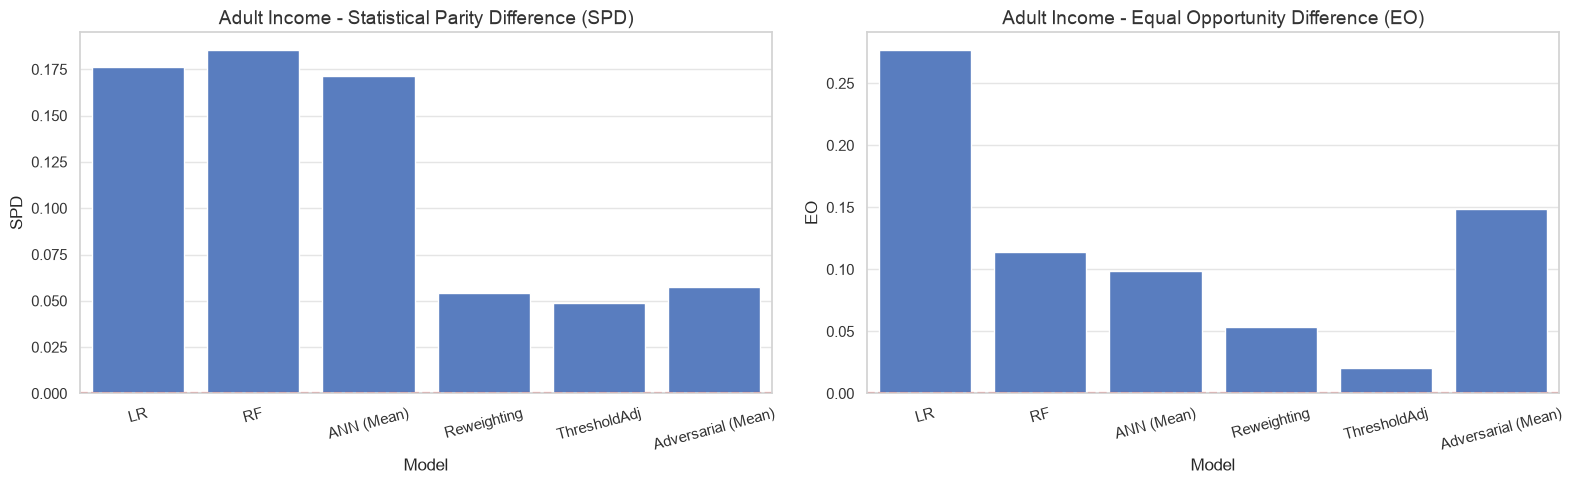

In [4]:
print("\n================ FETCHING ADULT DATASET ================")
cols_adult = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
              "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
              "hours-per-week", "native-country", "income"]
url_adult = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult = pd.read_csv(url_adult, names=cols_adult, na_values=" ?", skipinitialspace=True).dropna()

adult["income"] = adult["income"].apply(lambda x: 1 if ">50K" in x else 0)
prot_adult = adult["sex"].apply(lambda x: 1 if x == "Male" else 0)

le = LabelEncoder()
for col in adult.select_dtypes(include="object").columns:
    adult[col] = le.fit_transform(adult[col])

X_a = adult.drop("income", axis=1)
y_a = adult["income"]

X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a = train_test_split(
    X_a, y_a, prot_adult, stratify=prot_adult, test_size=0.2, random_state=42
)

scaler_a = StandardScaler()
X_train_scaled_a = scaler_a.fit_transform(X_train_a)
X_test_scaled_a = scaler_a.transform(X_test_a)

results_adult = run_fairness_pipeline(
    X_train_scaled_a, X_test_scaled_a, y_train_a, y_test_a,
    prot_train_a, prot_test_a, X_a.columns, "adult", "sex"
)
plot_comprehensive_metrics(results_adult, "Adult Income")


### 4.2 COMPAS Recidivism Dataset



================ FETCHING COMPAS DATASET ================



Processing Pipeline for: COMPAS...


Running Baseline ANN across multiple initializations...


Running Adversarial Debiasing across multiple initializations to track variance...


epoch 0; iter: 0; batch classifier loss: 0.723176; batch adversarial loss: 0.763967
epoch 1; iter: 0; batch classifier loss: 0.648777; batch adversarial loss: 0.798124
epoch 2; iter: 0; batch classifier loss: 0.576079; batch adversarial loss: 0.774619
epoch 3; iter: 0; batch classifier loss: 0.602787; batch adversarial loss: 0.730762
epoch 4; iter: 0; batch classifier loss: 0.562275; batch adversarial loss: 0.794437
epoch 5; iter: 0; batch classifier loss: 0.648851; batch adversarial loss: 0.703165
epoch 6; iter: 0; batch classifier loss: 0.601158; batch adversarial loss: 0.742447
epoch 7; iter: 0; batch classifier loss: 0.573879; batch adversarial loss: 0.696147


...

epoch 15; iter: 0; batch classifier loss: 0.616400; batch adversarial loss: 0.647246
epoch 16; iter: 0; batch classifier loss: 0.585862; batch adversarial loss: 0.609037
epoch 17; iter: 0; batch classifier loss: 0.703211; batch adversarial loss: 0.632115
epoch 18; iter: 0; batch classifier loss: 0.622183; batch adversarial loss: 0.579768
epoch 19; iter: 0; batch classifier loss: 0.604774; batch adversarial loss: 0.671319
epoch 20; iter: 0; batch classifier loss: 0.573950; batch adversarial loss: 0.602122
epoch 21; iter: 0; batch classifier loss: 0.570322; batch adversarial loss: 0.659484
epoch 22; iter: 0; batch classifier loss: 0.643342; batch adversarial loss: 0.627445


epoch 23; iter: 0; batch classifier loss: 0.644414; batch adversarial loss: 0.659958
epoch 24; iter: 0; batch classifier loss: 0.604433; batch adversarial loss: 0.688655
epoch 25; iter: 0; batch classifier loss: 0.629499; batch adversarial loss: 0.652267
epoch 26; iter: 0; batch classifier loss: 0.621877; batch adversarial loss: 0.665690
epoch 27; iter: 0; batch classifier loss: 0.655985; batch adversarial loss: 0.625486
epoch 28; iter: 0; batch classifier loss: 0.659231; batch adversarial loss: 0.604761
epoch 29; iter: 0; batch classifier loss: 0.593924; batch adversarial loss: 0.671231
epoch 30; iter: 0; batch classifier loss: 0.561352; batch adversarial loss: 0.632814


epoch 31; iter: 0; batch classifier loss: 0.650220; batch adversarial loss: 0.685899
epoch 32; iter: 0; batch classifier loss: 0.680905; batch adversarial loss: 0.651198
epoch 33; iter: 0; batch classifier loss: 0.596003; batch adversarial loss: 0.688239
epoch 34; iter: 0; batch classifier loss: 0.605155; batch adversarial loss: 0.621574
epoch 35; iter: 0; batch classifier loss: 0.564020; batch adversarial loss: 0.596099
epoch 36; iter: 0; batch classifier loss: 0.659730; batch adversarial loss: 0.653476
epoch 37; iter: 0; batch classifier loss: 0.590829; batch adversarial loss: 0.660052
epoch 38; iter: 0; batch classifier loss: 0.601027; batch adversarial loss: 0.633463


epoch 39; iter: 0; batch classifier loss: 0.589885; batch adversarial loss: 0.640465
epoch 40; iter: 0; batch classifier loss: 0.670571; batch adversarial loss: 0.628226
epoch 41; iter: 0; batch classifier loss: 0.568981; batch adversarial loss: 0.664578
epoch 42; iter: 0; batch classifier loss: 0.609462; batch adversarial loss: 0.647300
epoch 43; iter: 0; batch classifier loss: 0.591597; batch adversarial loss: 0.610849
epoch 44; iter: 0; batch classifier loss: 0.565808; batch adversarial loss: 0.613258
epoch 45; iter: 0; batch classifier loss: 0.608692; batch adversarial loss: 0.636585
epoch 46; iter: 0; batch classifier loss: 0.585421; batch adversarial loss: 0.607692


epoch 47; iter: 0; batch classifier loss: 0.646268; batch adversarial loss: 0.628500
epoch 48; iter: 0; batch classifier loss: 0.549313; batch adversarial loss: 0.650158
epoch 49; iter: 0; batch classifier loss: 0.550647; batch adversarial loss: 0.616239

=== COMPAS DATASET METRICS (IEEE Reviewer Format) ===
             Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
                LR         0.168         0.594         0.187         0.150         0.680             0.666         0.343
                RF         0.065         0.844         0.085         0.051         0.634             0.623         0.251
        ANN (Mean) 0.184 ± 0.013 0.591 ± 0.031 0.217 ± 0.017 0.167 ± 0.013 0.680 ± 0.001     0.669 ± 0.003 0.345 ± 0.004
       Reweighting         0.056         0.860         0.030         0.072         0.658             0.643         0.297
      ThresholdAdj         0.036         0.884         0.026         0.015         0.

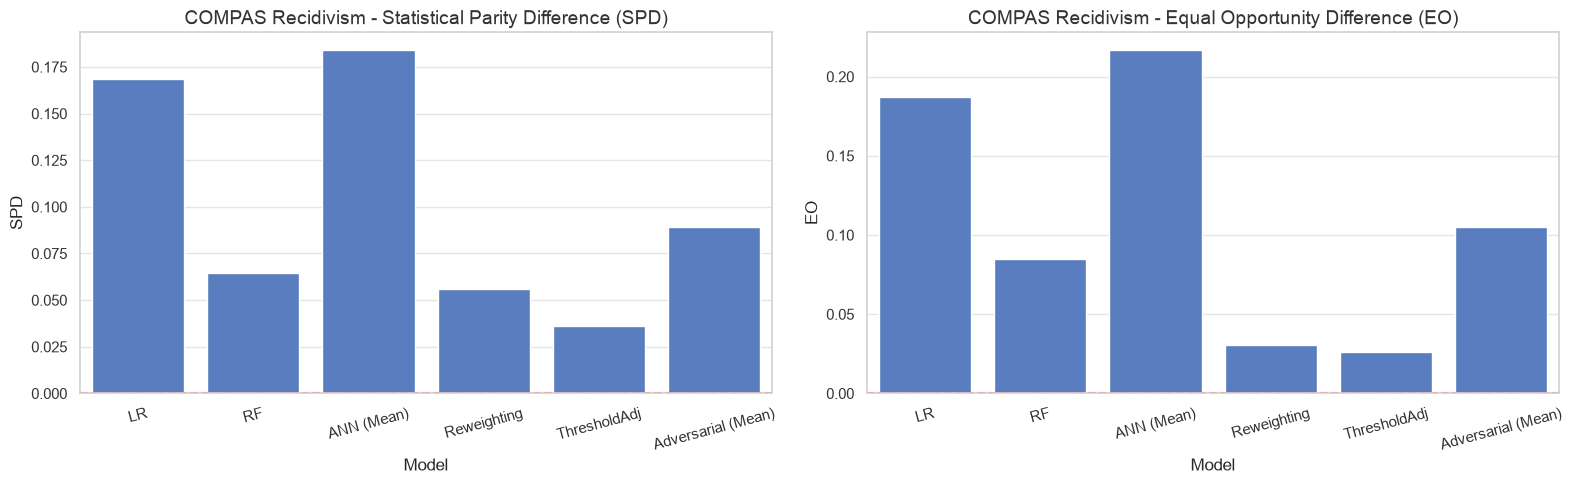

In [5]:
print("\n================ FETCHING COMPAS DATASET ================")
url_compas = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas = pd.read_csv(url_compas)[["age", "race", "sex", "priors_count", "two_year_recid"]].dropna()

compas["race"] = compas["race"].apply(lambda x: 1 if x == "Caucasian" else 0)
compas["sex"] = compas["sex"].apply(lambda x: 1 if x == "Male" else 0)

X_c = compas.drop("two_year_recid", axis=1)
y_c = compas["two_year_recid"]
prot_compas = compas["race"]

X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c = train_test_split(
    X_c, y_c, prot_compas, stratify=prot_compas, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

results_compas = run_fairness_pipeline(
    X_train_scaled_c, X_test_scaled_c, y_train_c, y_test_c,
    prot_train_c, prot_test_c, X_c.columns, "compas", "race"
)
plot_comprehensive_metrics(results_compas, "COMPAS Recidivism")


### 4.3 Statlog German Credit Dataset



================ FETCHING GERMAN CREDIT DATASET ================



Processing Pipeline for: GERMAN...
Running Baseline ANN across multiple initializations...


Running Adversarial Debiasing across multiple initializations to track variance...


epoch 0; iter: 0; batch classifier loss: 0.662393; batch adversarial loss: 0.541422
epoch 1; iter: 0; batch classifier loss: 0.643332; batch adversarial loss: 0.518904
epoch 2; iter: 0; batch classifier loss: 0.578952; batch adversarial loss: 0.573613
epoch 3; iter: 0; batch classifier loss: 0.551550; batch adversarial loss: 0.479644
epoch 4; iter: 0; batch classifier loss: 0.492158; batch adversarial loss: 0.605414
epoch 5; iter: 0; batch classifier loss: 0.489459; batch adversarial loss: 0.531475
epoch 6; iter: 0; batch classifier loss: 0.480058; batch adversarial loss: 0.466454
epoch 7; iter: 0; batch classifier loss: 0.473489; batch adversarial loss: 0.469878
epoch 8; iter: 0; batch classifier loss: 0.543516; batch adversarial loss: 0.520386
epoch 9; iter: 0; batch classifier loss: 0.498210; batch adversarial loss: 0.524154
epoch 10; iter: 0; batch classifier loss: 0.452963; batch adversarial loss: 0.563385
epoch 11; iter: 0; batch classifier loss: 0.491692; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.655242; batch adversarial loss: 0.828944
epoch 1; iter: 0; batch classifier loss: 0.634616; batch adversarial loss: 0.871761
epoch 2; iter: 0; batch classifier loss: 0.596264; batch adversarial loss: 0.900859
epoch 3; iter: 0; batch classifier loss: 0.546856; batch adversarial loss: 0.855535
epoch 4; iter: 0; batch classifier loss: 0.550675; batch adversarial loss: 0.886354
epoch 5; iter: 0; batch classifier loss: 0.502375; batch adversarial loss: 0.861877
epoch 6; iter: 0; batch classifier loss: 0.534859; batch adversarial loss: 0.851128
epoch 7; iter: 0; batch classifier loss: 0.495331; batch adversarial loss: 0.854062
epoch 8; iter: 0; batch classifier loss: 0.495555; batch adversarial loss: 0.855307
epoch 9; iter: 0; batch classifier loss: 0.638455; batch adversarial loss: 0.893569
epoch 10; iter: 0; batch classifier loss: 0.464098; batch adversarial loss: 0.825485
epoch 11; iter: 0; batch classifier loss: 0.540139; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.662888; batch adversarial loss: 0.674006
epoch 1; iter: 0; batch classifier loss: 0.572234; batch adversarial loss: 0.602568
epoch 2; iter: 0; batch classifier loss: 0.608287; batch adversarial loss: 0.604838
epoch 3; iter: 0; batch classifier loss: 0.525570; batch adversarial loss: 0.619835
epoch 4; iter: 0; batch classifier loss: 0.581322; batch adversarial loss: 0.615894
epoch 5; iter: 0; batch classifier loss: 0.542765; batch adversarial loss: 0.620867
epoch 6; iter: 0; batch classifier loss: 0.489276; batch adversarial loss: 0.586974
epoch 7; iter: 0; batch classifier loss: 0.532167; batch adversarial loss: 0.577341
epoch 8; iter: 0; batch classifier loss: 0.465078; batch adversarial loss: 0.595087
epoch 9; iter: 0; batch classifier loss: 0.452747; batch adversarial loss: 0.643485
epoch 10; iter: 0; batch classifier loss: 0.498479; batch adversarial loss: 0.582257
epoch 11; iter: 0; batch classifier loss: 0.515827; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.731406; batch adversarial loss: 0.688431
epoch 1; iter: 0; batch classifier loss: 0.646395; batch adversarial loss: 0.691959
epoch 2; iter: 0; batch classifier loss: 0.576988; batch adversarial loss: 0.706129
epoch 3; iter: 0; batch classifier loss: 0.564677; batch adversarial loss: 0.715342
epoch 4; iter: 0; batch classifier loss: 0.534084; batch adversarial loss: 0.697684
epoch 5; iter: 0; batch classifier loss: 0.483461; batch adversarial loss: 0.674313
epoch 6; iter: 0; batch classifier loss: 0.531610; batch adversarial loss: 0.728716
epoch 7; iter: 0; batch classifier loss: 0.492022; batch adversarial loss: 0.676558
epoch 8; iter: 0; batch classifier loss: 0.549503; batch adversarial loss: 0.755989
epoch 9; iter: 0; batch classifier loss: 0.393395; batch adversarial loss: 0.647617
epoch 10; iter: 0; batch classifier loss: 0.456719; batch adversarial loss: 0.679646
epoch 11; iter: 0; batch classifier loss: 0.479182; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.709609; batch adversarial loss: 0.598132
epoch 1; iter: 0; batch classifier loss: 0.659847; batch adversarial loss: 0.581424
epoch 2; iter: 0; batch classifier loss: 0.625964; batch adversarial loss: 0.613313
epoch 3; iter: 0; batch classifier loss: 0.630137; batch adversarial loss: 0.613392
epoch 4; iter: 0; batch classifier loss: 0.582942; batch adversarial loss: 0.612330
epoch 5; iter: 0; batch classifier loss: 0.577803; batch adversarial loss: 0.570329
epoch 6; iter: 0; batch classifier loss: 0.578606; batch adversarial loss: 0.583672
epoch 7; iter: 0; batch classifier loss: 0.500473; batch adversarial loss: 0.590750
epoch 8; iter: 0; batch classifier loss: 0.546886; batch adversarial loss: 0.548641
epoch 9; iter: 0; batch classifier loss: 0.531478; batch adversarial loss: 0.540148
epoch 10; iter: 0; batch classifier loss: 0.565996; batch adversarial loss: 0.578363
epoch 11; iter: 0; batch classifier loss: 0.568453; batch adversarial loss:


=== GERMAN DATASET METRICS (IEEE Reviewer Format) ===
             Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
                LR         0.089         0.896         0.026         0.050         0.805             0.691         0.458
                RF         0.279         0.675         0.193         0.253         0.795             0.696         0.440
        ANN (Mean) 0.185 ± 0.038 0.773 ± 0.044 0.163 ± 0.059 0.135 ± 0.035 0.764 ± 0.011     0.674 ± 0.017 0.370 ± 0.031
       Reweighting         0.062         0.927         0.026         0.015         0.800             0.682         0.441
      ThresholdAdj         0.033         0.958         0.015         0.020         0.800             0.711         0.461
Adversarial (Mean) 0.179 ± 0.169 0.804 ± 0.173 0.128 ± 0.110 0.207 ± 0.163 0.787 ± 0.026     0.674 ± 0.027 0.413 ± 0.062


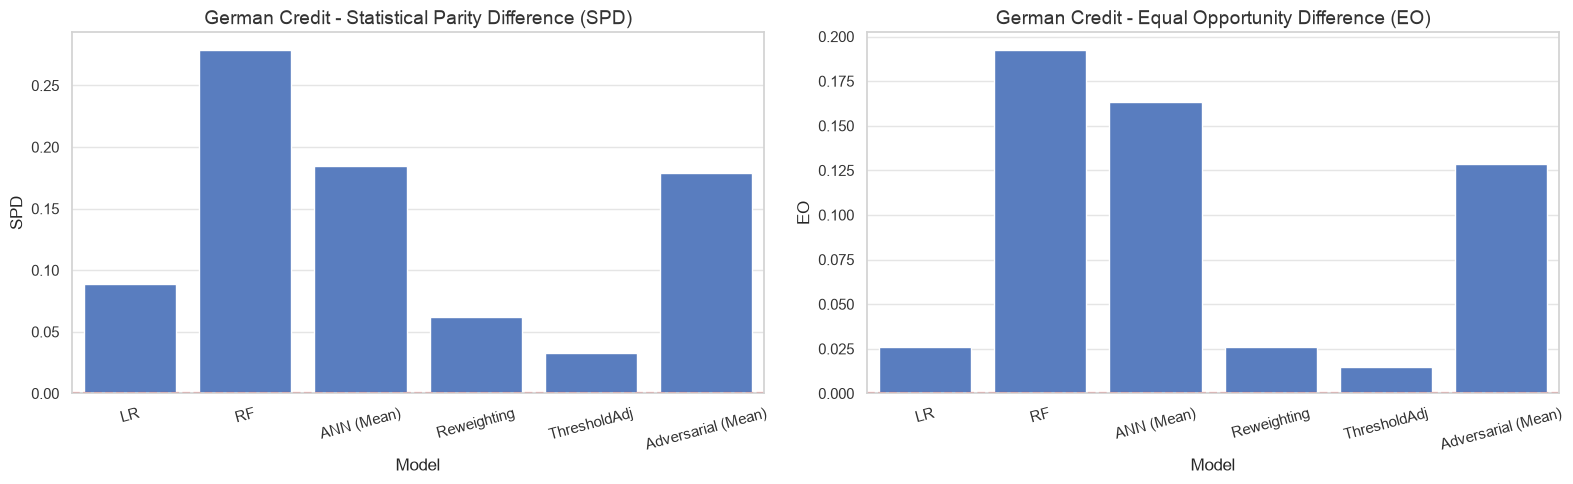

In [6]:
print("\n================ FETCHING GERMAN CREDIT DATASET ================")
url_german = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
cols_german = [f"feature_{i}" for i in range(1, 21)] + ["credit_risk"]
german = pd.read_csv(url_german, sep=' ', names=cols_german, header=None)

# Rename features so SHAP plots generate human-readable axes
german.rename(columns={"feature_13": "age", "feature_1": "checking_account_status"}, inplace=True)

# 1 = Good Credit (Favorable outcome), 2 = Bad Credit (Unfavorable outcome)
german["credit_risk"] = german["credit_risk"].apply(lambda x: 1 if x == 1 else 0)

# Age > 25 is Privileged (1)
prot_german = german["age"].apply(lambda x: 1 if x > 25 else 0)

le_german = LabelEncoder()
for col in german.select_dtypes(include="object").columns:
    german[col] = le_german.fit_transform(german[col])

X_g = german.drop("credit_risk", axis=1)
y_g = german["credit_risk"]

X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g = train_test_split(
    X_g, y_g, prot_german, stratify=prot_german, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_scaled_g = scaler_g.fit_transform(X_train_g)
X_test_scaled_g = scaler_g.transform(X_test_g)

results_german = run_fairness_pipeline(
    X_train_scaled_g, X_test_scaled_g, y_train_g, y_test_g,
    prot_train_g, prot_test_g, X_g.columns, "german", "age"
)
plot_comprehensive_metrics(results_german, "German Credit")


## 5. SHAP Interaction Analysis (Explainability & Indirect Bias)

We compute and plot SHAP interactions to explain how key features interact and potentially introduce indirect bias in Random Forest model predictions.



Computing SHAP Interactions for ADULT...


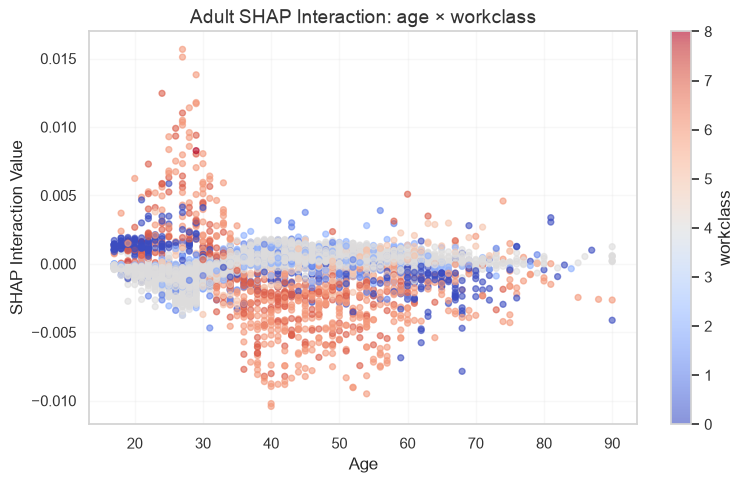


Computing SHAP Interactions for COMPAS...


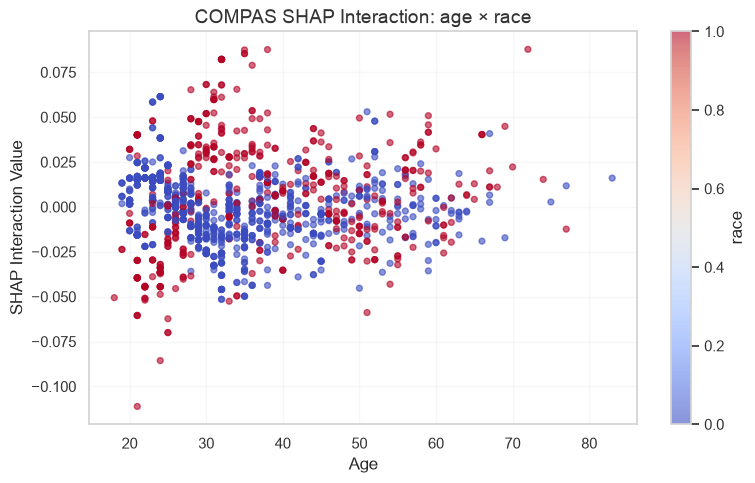


Computing SHAP Interactions for GERMAN_CREDIT...


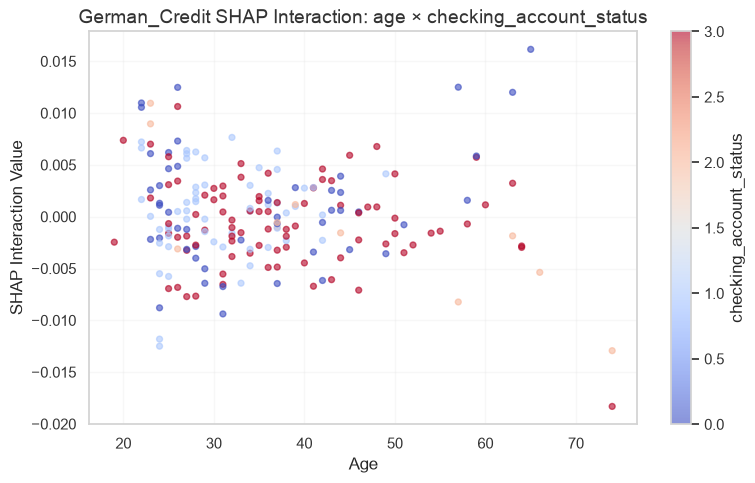

In [7]:
def generate_shap_interactions(X_train, y_train, X_test, feature_names, dataset_name, focus_features):
    """
    Generate SHAP interaction plots.
    """
    print(f"\nComputing SHAP Interactions for {dataset_name.upper()}...")

    rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf_model)
    interaction_values = explainer.shap_interaction_values(X_test)

    if isinstance(interaction_values, list):
        interaction_values = interaction_values[1]
    elif interaction_values.ndim == 4:
        interaction_values = interaction_values[:, :, :, 1]

    idx_0 = feature_names.get_loc(focus_features[0])
    idx_1 = feature_names.get_loc(focus_features[1])

    interaction_effects = interaction_values[:, idx_0, idx_1]

    x_data = X_test.iloc[:, idx_0].to_numpy()
    c_data = X_test.iloc[:, idx_1].to_numpy()
    y_data = np.asarray(interaction_effects).reshape(-1)

    n = min(len(x_data), len(y_data), len(c_data))
    x_data = x_data[:n]; y_data = y_data[:n]; c_data = c_data[:n]

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(x_data, y_data, c=c_data, cmap="coolwarm", alpha=0.6, s=18)
    
    plt.colorbar(scatter, label=focus_features[1])
    plt.xlabel(focus_features[0].replace("_", " ").title())
    plt.ylabel("SHAP Interaction Value")
    plt.title(f"{dataset_name} SHAP Interaction: {focus_features[0]} \u00d7 {focus_features[1]}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower()}_shap_interactions.png", dpi=300)
    plt.show()

# Generate the 3 SHAP plots
adult_feature_names = X_a.columns
generate_shap_interactions(X_train_a, y_train_a, X_test_a, adult_feature_names, "Adult", ["age", "workclass"])

compas_feature_names = X_c.columns
generate_shap_interactions(X_train_c, y_train_c, X_test_c, compas_feature_names, "COMPAS", ["age", "race"])

german_feature_names = X_g.columns
generate_shap_interactions(X_train_g, y_train_g, X_test_g, german_feature_names, "German_Credit", ["age", "checking_account_status"])


## 6. Causal Validation via Feature Ablation

To empirically validate the proxy features identified via SHAP interaction analysis, we perform a feature ablation study. We remove the suspected demographic proxy variables from the training data, retrain the models from scratch, and evaluate the change in accuracy and demographic disparity (Statistical Parity Difference).

If the Statistical Parity Difference decreases significantly while maintaining reasonable accuracy, it empirically confirms that the feature functioned as an active proxy for demographic bias.


In [8]:
def run_ablation_study(X_train, X_test, y_train, y_test, prot_train, prot_test, proxy_col, dataset_name):
    print(f"\n--- Running Ablation Study for {dataset_name.upper()} (Removing Proxy: {proxy_col}) ---")
    
    # Train Random Forest baseline (matching explainability model)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    spd_base, di_base, eo_base, aod_base = fairness_metrics(y_test, y_pred, prot_test)
    acc_base = accuracy_score(y_test, y_pred)
    
    # Train ablated model
    X_train_ablated = X_train.drop(columns=[proxy_col])
    X_test_ablated = X_test.drop(columns=[proxy_col])
    
    rf_ablated = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_ablated.fit(X_train_ablated, y_train)
    y_pred_ablated = rf_ablated.predict(X_test_ablated)
    spd_abl, di_abl, eo_abl, aod_abl = fairness_metrics(y_test, y_pred_ablated, prot_test)
    acc_abl = accuracy_score(y_test, y_pred_ablated)
    
    results = pd.DataFrame({
        "Metric": ["Accuracy", "SPD (Parity)", "DI (Impact)", "EO (Opportunity)"],
        "Original": [acc_base, spd_base, di_base, eo_base],
        "Ablated (No Proxy)": [acc_abl, spd_abl, di_abl, eo_abl],
        "Delta": [acc_abl - acc_base, spd_abl - spd_base, di_abl - di_base, eo_abl - eo_base]
    })
    
    print(results.to_string(index=False))
    
    # Save ablation study results to CSV
    results.to_csv(f"{dataset_name.lower()}_ablation_results.csv", index=False)
    return results

print("\n=== CAUSAL VALIDATION ABLATION STUDIES ===")
# Adult Income Dataset (Proxy: workclass)
run_ablation_study(X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a, "workclass", "Adult")

# COMPAS Recidivism Dataset (Proxy: age)
run_ablation_study(X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c, "age", "COMPAS")

# Statlog German Credit Dataset (Proxy: checking_account_status)
run_ablation_study(X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g, "checking_account_status", "German_Credit")



=== CAUSAL VALIDATION ABLATION STUDIES ===

--- Running Ablation Study for ADULT (Removing Proxy: workclass) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.858283            0.857209 -0.001075
    SPD (Parity)  0.153223            0.155501  0.002278
     DI (Impact)  0.284139            0.285746  0.001607
EO (Opportunity)  0.094962            0.104160  0.009198

--- Running Ablation Study for COMPAS (Removing Proxy: age) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.652807            0.636868 -0.015939
    SPD (Parity)  0.124380            0.184604  0.060225
     DI (Impact)  0.716045            0.509097 -0.206948
EO (Opportunity)  0.152980            0.194950  0.041970

--- Running Ablation Study for GERMAN_CREDIT (Removing Proxy: checking_account_status) ---
          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.810000            0.785000 -0.025000
    SPD (Parity)  0.217024            0.235543  0.018519
     DI (Impact)  0.759193            0.743907 -0.015286
EO (Opportunity)  0.100410            0.191940  0.091530


,Metric,Original,Ablated (No Proxy),Delta
0,Accuracy,0.810000,0.785000,-0.025000
1,SPD (Parity),0.217024,0.235543,0.018519
2,DI (Impact),0.759193,0.743907,-0.015286
3,EO (Opportunity),0.100410,0.191940,0.091530
